In [1]:
import os
import joblib
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
DATA_PATH = "../data/processed/cleaned_data.csv"
PREPROCESSING_DIR = "../models/preprocessing"

df = pd.read_csv(DATA_PATH)

label_encoder = joblib.load(
    os.path.join(PREPROCESSING_DIR, "label_encoder.joblib")
)

print("Dataset shape:", df.shape)
print("Number of classes:", len(label_encoder.classes_))
print("Classes:")
print(label_encoder.classes_)

Dataset shape: (2830743, 79)
Number of classes: 15
Classes:
['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack - Brute Force' 'Web Attack - Sql Injection'
 'Web Attack - XSS']


In [4]:
import os

print("Searching preprocessing files...")
print("=" * 70)

for root, dirs, files in os.walk("../models"):
    for file in files:
        print(os.path.join(root, file))

Searching preprocessing files...
../models\logistic_regression.joblib
../models\anomaly\.gitkeep
../models\anomaly\isolation_forest.joblib
../models\preprocessing\.gitkeep
../models\preprocessing\label_encoder.joblib
../models\preprocessing\scaler.joblib
../models\supervised\.gitkeep
../models\supervised\lightgbm.joblib
../models\supervised\random_forest.joblib
../models\supervised\xgboost.joblib


In [5]:
# Load the already-trained XGBoost model
xgb_model = joblib.load("../models/supervised/xgboost.joblib")

# Recover the exact feature names used during training
FEATURES = xgb_model.get_booster().feature_names

print("Feature list recovered from XGBoost model!")
print("Number of features:", len(FEATURES))
print("\nFirst 10 features:")
print(FEATURES[:10])

Feature list recovered from XGBoost model!
Number of features: 45

First 10 features:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Flow Bytes/s']


In [6]:
# Recreate the exact feature matrix used by the trained models
X = df[FEATURES].copy()

print("Exact Phase 4 feature matrix recreated successfully!")
print("X shape:", X.shape)
print("y shape:", y_encoded.shape)
print("Number of features:", X.shape[1])

Exact Phase 4 feature matrix recreated successfully!
X shape: (2830743, 45)
y shape: (2830743,)
Number of features: 45


In [7]:
# Stage 1: Binary detection target
# 0 = BENIGN
# 1 = ATTACK

y_binary = (y_encoded != 0).astype(int)

print("Stage 1 target created successfully!")
print("\nClass distribution:")
print(pd.Series(y_binary).value_counts().sort_index())

print("\nClass meaning:")
print("0 = BENIGN")
print("1 = ATTACK")

Stage 1 target created successfully!

Class distribution:
0    2273097
1     557646
Name: count, dtype: int64

Class meaning:
0 = BENIGN
1 = ATTACK


In [8]:
from sklearn.model_selection import train_test_split

# Exact split used in previous phases
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_binary,
    test_size=0.30,
    random_state=42,
    stratify=y_binary
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Stage 1 split completed!")
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

print("\nBinary class distribution:")
print("Train:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest:")
print(pd.Series(y_test).value_counts().sort_index())

Stage 1 split completed!
Training: (1981520, 45)
Validation: (424611, 45)
Testing: (424612, 45)

Binary class distribution:
Train:
0    1591168
1     390352
Name: count, dtype: int64

Validation:
0    340964
1     83647
Name: count, dtype: int64

Test:
0    340965
1     83647
Name: count, dtype: int64


In [9]:
# Stage 1: Binary XGBoost detector

stage1_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print("Training Stage 1 XGBoost model...")

stage1_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("Stage 1 training completed!")

Training Stage 1 XGBoost model...
Stage 1 training completed!


In [10]:
# Stage 1 predictions
y_pred_stage1 = stage1_model.predict(X_test)

# Calculate metrics
stage1_accuracy = accuracy_score(y_test, y_pred_stage1)
stage1_precision = precision_score(y_test, y_pred_stage1, zero_division=0)
stage1_recall = recall_score(y_test, y_pred_stage1, zero_division=0)
stage1_f1 = f1_score(y_test, y_pred_stage1, zero_division=0)

print("=" * 60)
print("STAGE 1 — BINARY DETECTION RESULTS")
print("=" * 60)

print(f"Accuracy : {stage1_accuracy:.4f}")
print(f"Precision: {stage1_precision:.4f}")
print(f"Recall   : {stage1_recall:.4f}")
print(f"F1 Score : {stage1_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_stage1,
        target_names=["BENIGN", "ATTACK"],
        zero_division=0
    )
)

STAGE 1 — BINARY DETECTION RESULTS
Accuracy : 0.9993
Precision: 0.9976
Recall   : 0.9989
F1 Score : 0.9982

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    340965
      ATTACK       1.00      1.00      1.00     83647

    accuracy                           1.00    424612
   macro avg       1.00      1.00      1.00    424612
weighted avg       1.00      1.00      1.00    424612



In [11]:
STAGE1_MODEL_PATH = "../models/supervised/stage1_binary_xgboost.joblib"

joblib.dump(stage1_model, STAGE1_MODEL_PATH)

print("Stage 1 model saved successfully!")
print("Saved to:", STAGE1_MODEL_PATH)

Stage 1 model saved successfully!
Saved to: ../models/supervised/stage1_binary_xgboost.joblib


In [12]:
# Load the already-trained 15-class XGBoost model
STAGE2_MODEL_PATH = "../models/supervised/xgboost.joblib"

stage2_model = joblib.load(STAGE2_MODEL_PATH)

print("Stage 2 model loaded successfully!")
print("Model type:", type(stage2_model))
print("Number of classes:", len(stage2_model.classes_))
print("Classes:", stage2_model.classes_)

Stage 2 model loaded successfully!
Model type: <class 'xgboost.sklearn.XGBClassifier'>
Number of classes: 15
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [13]:
# Stage 1 prediction
stage1_predictions = stage1_model.predict(X_test)

# Stage 2 prediction
stage2_predictions = stage2_model.predict(X_test)

# Final two-stage prediction
final_predictions = stage2_predictions.copy()

# Samples detected as BENIGN by Stage 1 remain BENIGN
final_predictions[stage1_predictions == 0] = 0

print("Two-stage prediction completed!")
print("Total test samples:", len(final_predictions))
print("Final predictions generated:", len(final_predictions))

Two-stage prediction completed!
Total test samples: 424612
Final predictions generated: 424612


In [14]:
# Recreate the original 15-class target
y_multiclass = label_encoder.transform(df["Label"])

# Use the exact same split indices as the current X_test
_, X_temp_multi, _, y_temp_multi = train_test_split(
    X,
    y_multiclass,
    test_size=0.30,
    random_state=42,
    stratify=y_multiclass
)

_, X_test_multi, _, y_test_multi = train_test_split(
    X_temp_multi,
    y_temp_multi,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_multi
)

print("Multiclass test labels recreated!")
print("Test samples:", len(y_test_multi))
print("Number of classes:", len(np.unique(y_test_multi)))

Multiclass test labels recreated!
Test samples: 424612
Number of classes: 15


In [15]:
# Evaluate final two-stage predictions
two_stage_accuracy = accuracy_score(y_test_multi, final_predictions)
two_stage_precision = precision_score(
    y_test_multi,
    final_predictions,
    average="macro",
    zero_division=0
)
two_stage_recall = recall_score(
    y_test_multi,
    final_predictions,
    average="macro",
    zero_division=0
)
two_stage_f1 = f1_score(
    y_test_multi,
    final_predictions,
    average="macro",
    zero_division=0
)

print("=" * 65)
print("PHASE 8 — TWO-STAGE NIDS RESULTS")
print("=" * 65)

print(f"Accuracy        : {two_stage_accuracy:.4f}")
print(f"Macro Precision : {two_stage_precision:.4f}")
print(f"Macro Recall    : {two_stage_recall:.4f}")
print(f"Macro F1        : {two_stage_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_multi,
        final_predictions,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

PHASE 8 — TWO-STAGE NIDS RESULTS
Accuracy        : 0.6563
Macro Precision : 0.0671
Macro Recall    : 0.0670
Macro F1        : 0.0671

Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       0.80      0.80      0.80    340965
                       Bot       0.00      0.00      0.00       295
                      DDoS       0.05      0.05      0.05     19204
             DoS GoldenEye       0.00      0.00      0.00      1544
                  DoS Hulk       0.08      0.08      0.08     34661
          DoS Slowhttptest       0.01      0.00      0.00       825
             DoS slowloris       0.00      0.00      0.00       869
               FTP-Patator       0.01      0.01      0.01      1191
                Heartbleed       0.00      0.00      0.00         1
              Infiltration       0.00      0.00      0.00         5
                  PortScan       0.06      0.06      0.06     23840
               SSH-Patator

In [16]:
# Get the exact indices used in the Stage 1 split
all_indices = np.arange(len(X))

train_idx, temp_idx = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=42,
    stratify=y_binary
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=y_binary[temp_idx]
)

# Get the original 15-class labels for those exact test rows
y_test_multi_correct = y_multiclass[test_idx]

# Verify alignment
print("Correct test labels recreated!")
print("Test samples:", len(y_test_multi_correct))
print("Prediction samples:", len(final_predictions))
print("Labels match predictions:", len(y_test_multi_correct) == len(final_predictions))

Correct test labels recreated!
Test samples: 424612
Prediction samples: 424612
Labels match predictions: True


In [17]:
# Evaluate the correctly aligned two-stage predictions

two_stage_accuracy = accuracy_score(
    y_test_multi_correct,
    final_predictions
)

two_stage_precision = precision_score(
    y_test_multi_correct,
    final_predictions,
    average="macro",
    zero_division=0
)

two_stage_recall = recall_score(
    y_test_multi_correct,
    final_predictions,
    average="macro",
    zero_division=0
)

two_stage_f1 = f1_score(
    y_test_multi_correct,
    final_predictions,
    average="macro",
    zero_division=0
)

print("=" * 65)
print("PHASE 8 — CORRECTED TWO-STAGE NIDS RESULTS")
print("=" * 65)

print(f"Accuracy        : {two_stage_accuracy:.4f}")
print(f"Macro Precision : {two_stage_precision:.4f}")
print(f"Macro Recall    : {two_stage_recall:.4f}")
print(f"Macro F1        : {two_stage_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_multi_correct,
        final_predictions,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

PHASE 8 — CORRECTED TWO-STAGE NIDS RESULTS
Accuracy        : 0.9991
Macro Precision : 0.9527
Macro Recall    : 0.9008
Macro F1        : 0.9204

Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    340965
                       Bot       0.97      0.71      0.82       288
                      DDoS       1.00      1.00      1.00     19192
             DoS GoldenEye       1.00      0.99      1.00      1557
                  DoS Hulk       1.00      1.00      1.00     34782
          DoS Slowhttptest       0.99      0.99      0.99       779
             DoS slowloris       1.00      0.99      1.00       888
               FTP-Patator       1.00      1.00      1.00      1171
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.83      0.91         6
                  PortScan       0.99      1.00      1.00     23787
               S

In [18]:
# Save two-stage NIDS configuration

TWO_STAGE_CONFIG = {
    "stage1_model": "../models/supervised/stage1_binary_xgboost.joblib",
    "stage2_model": "../models/supervised/xgboost.joblib",
    "stage1_classes": {
        0: "BENIGN",
        1: "ATTACK"
    },
    "stage2_classes": {
        int(i): str(name)
        for i, name in enumerate(label_encoder.classes_)
    },
    "num_features": len(FEATURES),
    "random_state": 42
}

CONFIG_PATH = "../models/supervised/two_stage_config.joblib"

joblib.dump(TWO_STAGE_CONFIG, CONFIG_PATH)

print("Two-stage configuration saved successfully!")
print("Saved to:", CONFIG_PATH)

Two-stage configuration saved successfully!
Saved to: ../models/supervised/two_stage_config.joblib


In [19]:
# Save overall two-stage evaluation metrics

two_stage_results = pd.DataFrame({
    "Model": ["Two-Stage NIDS"],
    "Accuracy": [two_stage_accuracy],
    "Macro Precision": [two_stage_precision],
    "Macro Recall": [two_stage_recall],
    "Macro F1": [two_stage_f1]
})

RESULTS_PATH = "../reports/model_results/two_stage_results.csv"

two_stage_results.to_csv(RESULTS_PATH, index=False)

print("Two-stage evaluation results saved successfully!")
print("\nResults:")
print(two_stage_results.to_string(index=False))
print("\nSaved to:", RESULTS_PATH)

Two-stage evaluation results saved successfully!

Results:
         Model  Accuracy  Macro Precision  Macro Recall  Macro F1
Two-Stage NIDS  0.999051         0.952742      0.900824  0.920419

Saved to: ../reports/model_results/two_stage_results.csv


In [20]:
# Generate and save per-class classification results

report_dict = classification_report(
    y_test_multi_correct,
    final_predictions,
    labels=np.arange(len(label_encoder.classes_)),
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

class_results = pd.DataFrame(report_dict).transpose()

CLASS_RESULTS_PATH = "../reports/model_results/two_stage_classification_report.csv"

class_results.to_csv(CLASS_RESULTS_PATH)

print("Per-class results saved successfully!")
print("\nSaved to:", CLASS_RESULTS_PATH)

print("\nPer-class results:")
print(class_results.to_string())

Per-class results saved successfully!

Saved to: ../reports/model_results/two_stage_classification_report.csv

Per-class results:
                            precision    recall  f1-score        support
BENIGN                       0.999645  0.999449  0.999547  340965.000000
Bot                          0.966981  0.711806  0.820000     288.000000
DDoS                         0.999948  0.999792  0.999870   19192.000000
DoS GoldenEye                0.996141  0.994862  0.995501    1557.000000
DoS Hulk                     0.998593  0.999597  0.999095   34782.000000
DoS Slowhttptest             0.992308  0.993582  0.992944     779.000000
DoS slowloris                0.997740  0.994369  0.996052     888.000000
FTP-Patator                  1.000000  0.998292  0.999145    1171.000000
Heartbleed                   1.000000  1.000000  1.000000       2.000000
Infiltration                 1.000000  0.833333  0.909091       6.000000
PortScan                     0.994396  0.999664  0.997023   23787.0

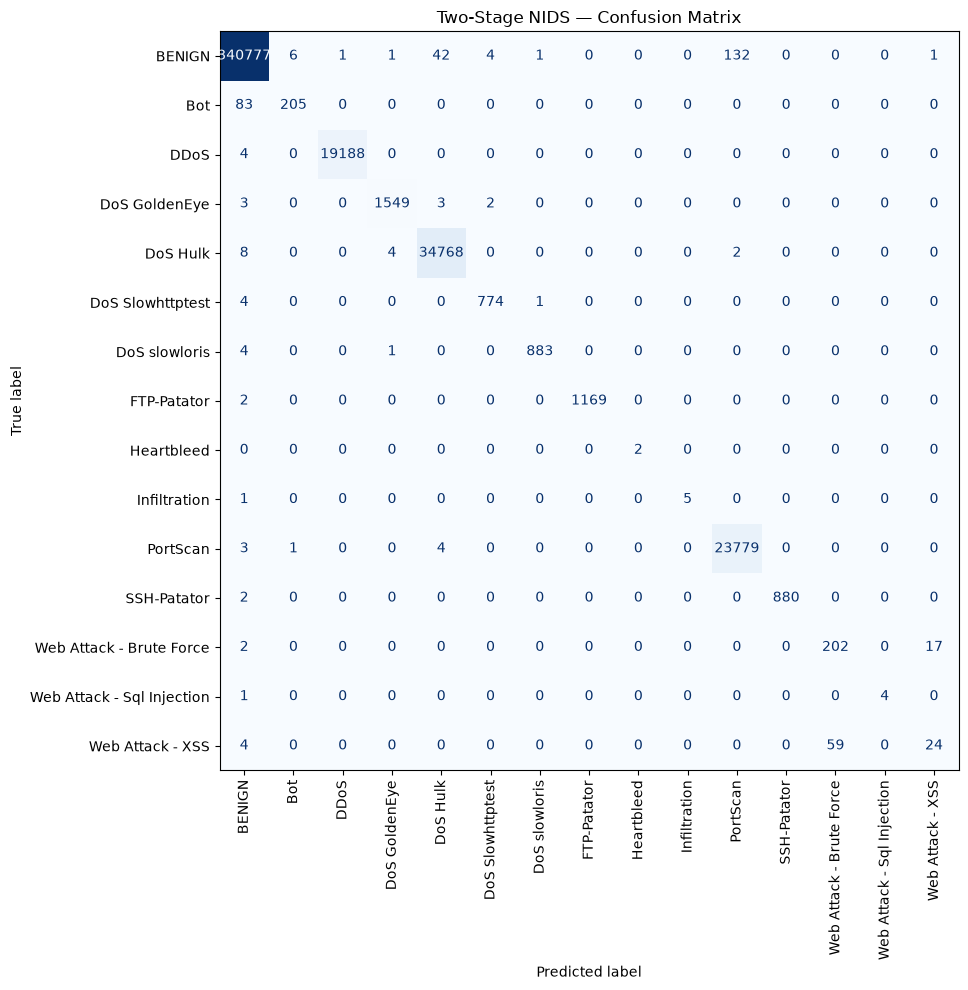

Confusion matrix saved successfully!
Saved to: ../reports/figures/two_stage_confusion_matrix.png


In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(
    y_test_multi_correct,
    final_predictions,
    labels=np.arange(len(label_encoder.classes_))
)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False
)

ax.set_title("Two-Stage NIDS — Confusion Matrix")
plt.tight_layout()

CM_PATH = "../reports/figures/two_stage_confusion_matrix.png"

plt.savefig(CM_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved successfully!")
print("Saved to:", CM_PATH)

In [22]:
import os

files_to_check = [
    "../models/supervised/stage1_binary_xgboost.joblib",
    "../models/supervised/xgboost.joblib",
    "../models/supervised/two_stage_config.joblib",
    "../reports/model_results/two_stage_results.csv",
    "../reports/model_results/two_stage_classification_report.csv",
    "../reports/figures/two_stage_confusion_matrix.png"
]

print("Phase 8 output files:\n")

for file in files_to_check:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗ MISSING:", file)

Phase 8 output files:

✓ ../models/supervised/stage1_binary_xgboost.joblib
✓ ../models/supervised/xgboost.joblib
✓ ../models/supervised/two_stage_config.joblib
✓ ../reports/model_results/two_stage_results.csv
✓ ../reports/model_results/two_stage_classification_report.csv
✓ ../reports/figures/two_stage_confusion_matrix.png


In [23]:
print("========== PHASE 8 FINAL VERIFICATION ==========")

print("\nStage 1: Binary Detection")
print("Accuracy :", round(accuracy_score(y_test, y_pred_stage1), 6))
print("Precision:", round(precision_score(y_test, y_pred_stage1), 6))
print("Recall   :", round(recall_score(y_test, y_pred_stage1), 6))
print("F1 Score :", round(f1_score(y_test, y_pred_stage1), 6))

print("\nStage 2: Attack Classification")
print("Classes:", len(label_encoder.classes_))

print("\nTwo-Stage NIDS")
print("Accuracy        :", round(accuracy_score(y_test_multi_correct, final_predictions), 6))
print("Macro Precision :", round(precision_score(
    y_test_multi_correct, final_predictions, average="macro", zero_division=0
), 6))
print("Macro Recall    :", round(recall_score(
    y_test_multi_correct, final_predictions, average="macro", zero_division=0
), 6))
print("Macro F1        :", round(f1_score(
    y_test_multi_correct, final_predictions, average="macro", zero_division=0
), 6))

print("\nOutput files verified: 6/6")
print("===============================================")

========== PHASE 8 FINAL VERIFICATION ==========

Stage 1: Binary Detection
Accuracy : 0.999298
Precision: 0.997576
Recall   : 0.998864
F1 Score : 0.99822

Stage 2: Attack Classification
Classes: 15

Two-Stage NIDS
Accuracy        : 0.999051
Macro Precision : 0.952742
Macro Recall    : 0.900824
Macro F1        : 0.920419

Output files verified: 6/6
